# MLonMCU

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tum-ei-eda/mlonmcu/blob/main/ipynb/Demo.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tum-ei-eda/mlonmcu/blob/main/ipynb/Demo.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
</table>

## Prerequisites

Before running this notebook, make sure to run the following steps:

1. Install the required software for your distribution:

   See main `README.md` file!
   
2. Clone this repository

   ```
   git clone https://github.com/tum-ei-eda/mlonmcu.git --recursive
   cd mlonmcu  # enter cloned repository
   ```
   
3. Setup and enter a new virtualenv (Python 3.7+) for using `mlonmcu`:

   ```
   python -m venv .venv
   source .venv/bin/activate
   ```
   
   Hint: You can also use a `conda` environment for this.
   
4. Install mlonmcu package

   ```
   make install  # alternative: python setup.py install
   ```
   
5. Install the required python packages:

   ```
   pip install -e ".[ipynb]"
   # or: 
   pip install -e "mlonmcu[ipynb]"
   ```
   
6. Launch this notebook in jupyter:

   ```
   jupyter notebook ipynb/Demo.ipynb
   ```

*Hint for Developers:* If you do not want to install MLonMCU first, you can just replace `mlonmcu` with `python -m mlonmcu.cli.main` in every command to just use the latest development version.

## Demonstration (Command Line)

### Preface

This guide should give an idea on the required steps to setup and use MLonMCU using the command line interface. Usage examples are provided as well.

### Initialize a MLonMCU environment

As MLonMCU requires a directory where dependencies, configurations, intermediate artifacts and results are stored, an environment needs to be initialized first. This also allows to use different configuration (e.g. enabled backends or supported features) for multiple environments.

Create and enter an environment diretcory first to initialize it afterwards:

In [ ]:
# WARNING: execute this only once! Alternatively remove the environment directory beforehand to start from scratch.
!test -d /home/ge96fak/Documents/Code/mlonmcu/mlonmcu_env && echo "Skipped initialization of environment" \
  || mlonmcu init /home/ge96fak/Documents/Code/mlonmcu/mlonmcu_env --non-interactive

%load_ext autoreload
%autoreload 2

When not using a notebook, the option `--non-interactive` can be omitted which allows to customize the initialization process interactively.

If the environment directory is not passed to the `mlonmcu` script, it will try to setup a `default` environment in the users home directory (On Ubuntu: `~/.config/mlonmcu/environments/default/`) instead. By providing a `--name` of the virtual environment if will be automatically registered in `~/.config/mlonmcy/environments.ini` for the current user which helps to find and distinguish multiple installed environments on a machine.

In the following the actual environment which should be used by the `mlonmcu` program has to be defined by the user either by defining the environment variable `MLONMCU_HOME` or by using the `-H` (`--home` or `--hint`) command line option. If none of this was done, the following rules are following to look for a suitable environment:

1. Check if `$MLONMCU_HOME` points to a valid environment
2. Use environment provided via the `-H` flag (path or registered name) if available
3. If the local working directory is the root of an environment, use this directory
4. If there is a default environment for the current user, fall back to this one instead

In [ ]:
# Use this for bash: `export MLONMCU_HOME=/tmp/mlonmcu_env`
%env MLONMCU_HOME=/home/ge96fak/Documents/Code/mlonmcu/mlonmcu_env

Registered environment can be listed via the command `mlonmcu env`. In addition there are possibilities to manually update entires in the environments file.

In [ ]:
!mlonmcu env

### Customizing the created MLonMCU environment (optional)

The environment was initialized by a template which can be found in the `templates/` directory of the repository chosen via the `--template` flag. Lets inspect the generated configuration file first:

In [ ]:
!cat $MLONMCU_HOME/environment.yml

The environment should work out of the box, but feel free to update the contents of the `environment.yml` file to achieve one of the following:

- Change the default paths used for dependencies, results, models,...
- Use different forks/versions of a repository
- Disable certain frameworks/backends to reduce the installation time in the next step.
- Define which features are supported for the given repositories
- Set default backends and targets
- Define a set of default configuration variables

To learn more about this, check out this document: `ENVIRONMENTS.md`

### Setting up all MLonMCU dependencies

Depending on the enabled backends and features, a different set of dependencies has to be installed. To reduce the management effort for the user, all these versions are installed and managed automatically using MLonMCU. To trigger this process, run the following in the command line. (This will take a very long time with all frameworks/targets/features enabled when invoked for the first time)

In [ ]:
!mlonmcu setup -v

Some things need to be considered here:
- Repositories are only cloned once, so upstream changes or updated urls/branches in the `environments.yml` are not detected automatically
- The flag `--rebuild` can be passed to `mlonmcu setup` to ensure that the setup routine of every dependency is triggered again. However this does not guarentee that all artifacts are properly updated. Also there is a `--task` option which allows to invoke individual tasks manually.
- To guarantee that the latest versions of a dependency are installed you can remove the `deps` directory manually or alternative use the provided `mlonmcu cleanup` utility. (Execute `mlonmcu cleanup --help` to learn more)
- In addition to the installed dependencies, a file named `cache.ini` can be found in the environments `deps/` directory. Here all paths to relevant dependencies are stored with their different sets of flags.

### Adding models to MLonMCU

By default, the `mlonmcu-models` repository (https://github.com/tum-ei-eda/mlonmcu-models) is cloned to each environment as its contents are designed to perfectly integrate into the MLonMCU flow. In addition a location in the users home directory (`~/.config/mlonmcu/models/` for Ubuntu) is also added to the search path as defined in the `environments.yml`. Feel free to add further model manually or alternatively clone a model-zoo (e.g. https://github.com/ARM-software/ML-zoo) to a random location on the disc and updating the list of model-paths in the environments' config file.

To list all available models in a environment, the `mlonmcu models` subcommand can be used:

In [ ]:
!mlonmcu models

The listed "Paths" should match the search paths defined in the `environments.yml` and are processed in the provided order. If there are multiple models of the same name, only the first one will be added to MLonMCU. By passing the `--detailed` flag to the command, additional information will be shown for each entry.

TODO: allow to search/filter for models by passing an extra arg

In addition to individual models, predefined model-groups are also available. I.e. the MLPerf Tiny benchmark defined here:

In [ ]:
!cat $MLONMCU_HOME/models/modelgroups.yml

Feel free to manualy define further model-groups for your needs.

### Running the MLonMCU flow

The MLonMCU flow is a major part of the tool and therefore explained by several examples, starting with minimal use cases before discussing more complex examples later.

**Invoke a single model on the default backend/target**

In [92]:
#!mlonmcu flow run resnet --backend ireellvmc
# !mlonmcu flow run sine_model --backend ireevmvx --config ireevmvx.compiler_mode=abyzft --verbose
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=abyzft \
  --config ireellvmc.abft_enable_analysis=false -l abyzft

/data/home/ge96fak/Documents/Code/mlonmcu/mlonmcu/environment/templates.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO - Loading environment cache from file
INFO - Successfully initialized cache
IREEBackend.add_platform_config
INFO - [session-511]  Processing stage LOAD
INFO - [session-511]  Processing stage BUILD
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
artifacts [Artifact(model.mlir, fmt=2, flags={}), Artifact(model.mlirbc, fmt=2048, flags={}), Artifact(model.img2col.mlir, fmt=2, flags={}), Artifact(model.instrumentable.mlir, fmt=2, flags={}), Artifact(model.tiled.mlir, fmt=2, flags={}), Artifact(model.instrum

In [93]:
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=abft \
  --config ireellvmc.abft_enable_analysis=false -l abft

/data/home/ge96fak/Documents/Code/mlonmcu/mlonmcu/environment/templates.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO - Loading environment cache from file
INFO - Successfully initialized cache
IREEBackend.add_platform_config
INFO - [session-513]  Processing stage LOAD
INFO - [session-513]  Processing stage BUILD
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
artifacts [Artifact(model.mlir, fmt=2, flags={}), Artifact(model.mlirbc, fmt=2048, flags={}), Artifact(model.img2col.mlir, fmt=2, flags={}), Artifact(model.instrumentable.mlir, fmt=2, flags={}), Artifact(model.tiled.mlir, fmt=2, flags={}), Artifact(model.instrum

In [91]:
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=baseline \
  --config ireellvmc.abft_enable_analysis=false -l baseline

/data/home/ge96fak/Documents/Code/mlonmcu/mlonmcu/environment/templates.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO - Loading environment cache from file
INFO - Successfully initialized cache
IREEBackend.add_platform_config
INFO - [session-509]  Processing stage LOAD
INFO - [session-509]  Processing stage BUILD
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
artifacts [Artifact(model.mlir, fmt=2, flags={}), Artifact(model.mlirbc, fmt=2048, flags={}), Artifact(model_static_lib.o, fmt=2048, flags={}), Artifact(model_static_lib.h, fmt=2, flags={}), Artifact(model_emitc.h, fmt=2, flags={}), Artifact(iree_wrapper.c, fmt=

In [ ]:
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=freivald \
  --config ireellvmc.abft_enable_analysis=false \
  -l freivald_binary \
  --config ireellvmc.freivalds_scaling_mode=binary

In [86]:
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=freivald \
  --config ireellvmc.abft_enable_analysis=false \
  -l freivald_standard_4 \
  --config ireellvmc.freivalds_scaling_mode=standard \
  --config ireellvmc.freivalds_num_checks=4 \
  --config ireellvmc.strip_assertions=false

/data/home/ge96fak/Documents/Code/mlonmcu/mlonmcu/environment/templates.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO - Loading environment cache from file
INFO - Successfully initialized cache
IREEBackend.add_platform_config
INFO - [session-505]  Processing stage LOAD
INFO - [session-505]  Processing stage BUILD
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
artifacts [Artifact(model.mlir, fmt=2, flags={}), Artifact(model.mlirbc, fmt=2048, flags={}), Artifact(model.img2col.mlir, fmt=2, flags={}), Artifact(model.instrumentable.mlir, fmt=2, flags={}), Artifact(model.tiled.mlir, fmt=2, flags={}), Artifact(model.instrum

In [87]:
!mlonmcu flow run sine_model --backend ireellvmc \
  --config ireellvmc.compiler_mode=freivald \
  --config ireellvmc.abft_enable_analysis=false \
  -l freivald_standard \
  --config ireellvmc.freivalds_scaling_mode=standard \
  --config ireellvmc.freivalds_num_checks=1 \
  --config ireellvmc.strip_assertions=false


/data/home/ge96fak/Documents/Code/mlonmcu/mlonmcu/environment/templates.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
INFO - Loading environment cache from file
INFO - Successfully initialized cache
IREEBackend.add_platform_config
INFO - [session-507]  Processing stage LOAD
INFO - [session-507]  Processing stage BUILD
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
WARNING - iree.version undefined, assuming v3.1
artifacts [Artifact(model.mlir, fmt=2, flags={}), Artifact(model.mlirbc, fmt=2048, flags={}), Artifact(model.img2col.mlir, fmt=2, flags={}), Artifact(model.instrumentable.mlir, fmt=2, flags={}), Artifact(model.tiled.mlir, fmt=2, flags={}), Artifact(model.instrum

While this looks pretty clean, in the background, there is a lot of thing being processed. You can find out more using the `--verbose` flag:

In [ ]:
!mlonmcu flow run --help

The report of a run is typically the first thing to check out after invoking MLonMCU. It will be automatically written to the `results` directory declared in the `environments.yml`:

In [ ]:
!ls $MLONMCU_HOME/results/*.csv

Let's define some helper functions to print these reports as a table. Of course you could also just open them i.e. with Excel! 

In [94]:
from helpers import tabularize_latest_report
from helpers import get_all_results, get_comparison_dfs, plot_comparison

In the following line the results or the latest run should be printed as a Pandas dataframe:

In [95]:
get_all_results()

,Run,Model,Frontend,Framework,Backend,Platform,Target,Total Cycles,Total Instructions,Total CPI,...,ROM misc,RAM data,RAM zero-init data,Features,Config,Postprocesses,Comment,Incomplete,Failing,Reason
0,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,103444.0,103444.0,1.0,...,20.0,4780.0,1196.0,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,NaN,NaN,NaN
1,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,NaN,NaN,NaN,...,NaN,NaN,NaN,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,True,True,AssertionError @ BUILD
2,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,109110.0,109110.0,1.0,...,20.0,4828.0,1196.0,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,NaN,NaN,NaN
3,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,111553.0,111553.0,1.0,...,20.0,4844.0,1196.0,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,NaN,NaN,NaN
4,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,109110.0,109110.0,1.0,...,20.0,4828.0,1196.0,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,NaN,NaN,NaN
5,0,sine_model,tflite,iree,ireellvmc,mlif,etiss,120658.0,120658.0,1.0,...,20.0,4860.0,1196.0,[],{'sine_model.output_types': {'Identity': 'floa...,[],-,NaN,NaN,NaN


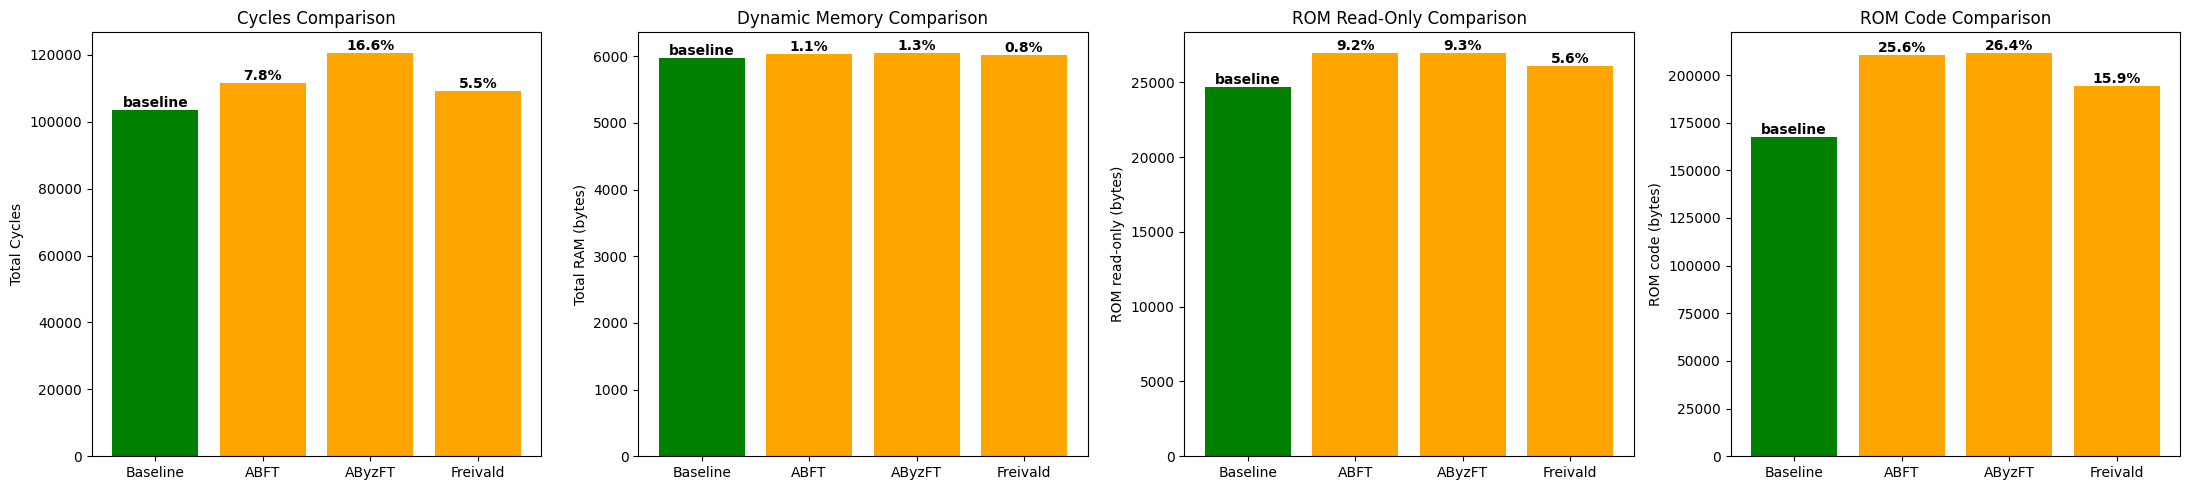

In [96]:
results = get_comparison_dfs(
    {
        "Baseline": "baseline.csv",
        "ABFT": "abft.csv",
        "AByzFT": "abyzft.csv",
        "Freivald": "freivald_standard.csv",
        #"Freivald (4x)": "freivald_standard_4.csv",
        # "Freivald Binary": "freivald_binary.csv",
    },
    as_dict=True,
)
plot_comparison(results=results, baseline_label="Baseline")


The artifacts for every invocation of the MLonMCU flow can be found in directory inside the environment. Your can find the latest files like this:

In [ ]:
# Install the `tree` package before running this cell!
# !tree -L 3 $MLONMCU_HOME/temp/sessions/latest/

However there is a more comfortable way to do this: `mlonmcu export`

In [ ]:
!mkdir -p /tmp/some_directory
!mlonmcu export /tmp/some_directory --run -f # By default this exports the latest run of the latest session

Check out `mlonmcu export --help` to learn learn how to get the most out of this command. There is also a utility called `mlonmcu cleanup` which helps to get rid of old files after exporting the useful ones.

There exist multiple stages which can be processed. The subcommand passed to `mlonmcu flow` defines the stage where the flow should stop. If you are only interested in intermediate artifacts of the process, use one of the following:

```
mlonmcu flow load  # only process the model with the frontend
mlonmcu flow build  # invoke the chosen backend to generate code
mlonmcu flow compile  # (cross-)compile the code for the chosen target
```

Further commands are available to achive further behavior:

```
mlonmcu flow test  # use provided model-data to invoke the models comparing their outputs with a golden reference
```

**Explicitly specify the backend and target to use for the flow**

In [ ]:
!mlonmcu flow run sine_model --backend tvmaot --target host_x86

**Enable certain features for all defined runs**

In [ ]:
!mlonmcu flow run toycar --backend tvmaot --target etiss_pulpino --feature unpacked_api

**Add additional configuration options to customize internal components**

In [ ]:
!mlonmcu flow run resnet --backend tvmaot --config tvmaot.target_device=arm_cpu

Instead of defining certain key-value pass on each command line, feel free to use the `vars:` property defined in the `environment.yml` to achieve the same result.

**Invoke multiple models on multiple backends/targets**

In [ ]:
!time mlonmcu flow run resnet toycar --backend tvmaot --backend tflmi  --target etiss_pulpino

**Exploit parallelism to reduce the processing time**

In [ ]:
!time mlonmcu flow run resnet toycar --backend tvmaot --backend tflmi --target etiss_pulpino --parallel --config runs_per_stage=0 --config mlif.num_threads=2

**Display progress information for long-running benchmarks**

**WARNING:** The progress output looks bit broken inside the Jupyter Notebook but should look fine on the command-line.

In [ ]:
!mlonmcu flow run resnet toycar micro_speech --progress --backend tvmaot --backend tflmi --target etiss_pulpino --target host_x86 --parallel --config mlif.num_threads=2

**Inspecting and exporting results and intermediate artifacts**

In [ ]:
# !mlonmcu export --session 0 --run 0 run.zip  # Export run 0 from session 0 to a zip archive
# !mlonmcu export --session 1 session.zip  # Export every run of session 1 to a zip archive
# !mlonmcu export session/  # Export the latest session to a directory

**Cleanup an MLonMCU environment**

In [ ]:
# !mlonmcu cleanup  # Interactively clean sessions
# !mlonmcu cleanup --force  # Clean all sessions
# !mlonmcu cleanup --keep 10 --force  # Keep only the latest 10 sessions
# !mlonmcu cleanup --dependencies  # Remove every installed dependency

**Internal command line interfaces**

In [ ]:
!python -m mlonmcu.target.riscv.etiss_pulpino -h

In [ ]:
!python -m mlonmcu.flow.tvm.backend.tvmaot -h

## Demonstration (Python API)

### Preface

While it is also possible to initialize and setup an MLonMCU environment via Python, it is highly recommended to use the provided command line interfaces for these steps. The following examples demonstrate how to use the MLonMCU flow from within a Python program which enables more customizations of the internal features via scripting.

In [ ]:
%env MLONMCU_HOME=/tmp/mlonmcu_env

### Open a MLonMCU context to load the environment

In [ ]:
import mlonmcu.context

with mlonmcu.context.MlonMcuContext() as context:
    pass

### Running the MLonMCU flow

In [ ]:
import mlonmcu.context
from mlonmcu.session.run import RunStage

MODEL_NAMES = ["magic_wand", "micro_speech", "toycar"]

with mlonmcu.context.MlonMcuContext() as context:
    with context.create_session() as session:
        for model_name in MODEL_NAMES:
            run = session.create_run(features=[], config={})

            run.add_frontend_by_name("tflite", context=context)

            run.add_model_by_name(model_name, context=context)
            run.add_backend_by_name("tvmaot", context=context)
            run.add_platform_by_name("mlif", context=context)
            run.add_target_by_name("etiss_pulpino", context=context)
            run.add_features_by_name(["debug"], context=context)
        session.process_runs(until=RunStage.RUN, context=context)
        report = session.get_reports()

Now we have the dataframe of the run we just defined and right in out python environment so we can have more fun with it.

In [ ]:
report.df

Let's add a quick visualization:

In [ ]:
import matplotlib.pyplot as plt

COLS = ["Cycles", "Total ROM", "Total RAM"]

fig, axes = plt.subplots(ncols=len(COLS))
plt.rcParams["figure.figsize"] = (15, 3)  # (w, h)


for i, col in enumerate(COLS):
    new_df = report.df[[col]].astype(float)
    new_df.index = MODEL_NAMES
    new_df.plot(kind="bar", ax=axes[i])